In [73]:
# 导入必要的库
import numpy as np                          # 数值计算库
from vpsto.vpsto import VPSTO, VPSTOOptions # VPSTO轨迹优化库
from vpsto.obf import OBF                   # 椭球基函数库
import matplotlib.pyplot as plt             # 绘图库
import matplotlib.patches as patches        # matplotlib几何图形补丁

PI = np.pi  # 定义π常量

In [74]:
# 定义2D机械臂类，包含正向运动学计算
class Manipulator():
    def __init__(self):
        # 机械臂链接长度：两段链接长度均为1
        self.l = np.array([1, 1]) # link lengths
        # 关节角度限制：第一关节[0, π]，第二关节[-π, 0]
        self.q_min = np.array([0., -np.pi])    # 关节角度下限
        self.q_max = np.array([np.pi, 0.])     # 关节角度上限
        self.danger_dist = 5 * 1e-2  # 定义安全距离

    # 定义机械臂的正向运动学
    def fk(self, q):
        """
        正向运动学函数：根据关节角度计算机械臂各关节的笛卡尔坐标位置
        参数：
        q: 2x1数组，包含两个关节的角度
        返回：3x2数组，包含基座、第一关节和末端执行器的二维位置
        """
        x0 = np.zeros(2)  # 基座位置（原点）
        # 第一关节位置：基座 + 第一段链接的笛卡尔位置
        x1 = x0 + self.l[0] * np.array([np.cos(q[0]), np.sin(q[0])])
        # 末端执行器位置：第一关节 + 第二段链接的笛卡尔位置
        x2 = x1 + self.l[1] * np.array([np.cos(q[0] + q[1]), np.sin(q[0] + q[1])])
        return np.vstack((x0, x1, x2))  # 返回所有关节的位置

# 创建机械臂实例并测试正向运动学
# mp = Manipulator()  # 创建机械臂实例
# q = np.array([np.pi/2, 0 ])  # 定义关节角度
# positions = mp.fk(q)  # 计算正向运动学，获取各关节位置
# print("关节位置：\n", positions)  # 打印关节位置
# print("pos维度：", positions.shape)  # 打印位置数组的维度


In [75]:
is_tested = 0
# 碰撞环境类：包含球形障碍物和工作空间边界
class CollisionEnvironment():
    def __init__(self,mp_danger_dist):
        # 球形障碍物的中心位置
        # self.x = np.array([1, 1.5])
        self.x = np.array([0.5, 0.5])
        # 球形障碍物的半径
        self.r = 0.1
        # 球形障碍物半径的平方（用于优化碰撞检测计算）
        self.r_sq = (self.r+mp_danger_dist)**2

        # 工作空间的边界限制
        self.x_min = np.array([-0.75, 0.])     # 工作空间最小边界
        self.x_max = np.array([1.5, 1.5])     # 工作空间最大边界

    def isCollision(self, pts):
        """
        检查线段是否与球形障碍物发生碰撞
        参数：
        pts: (n, 4)数组，每行包含一条线段的两个二维端点坐标
        返回：布尔数组，表示每条线段是否与障碍物碰撞
        """
        # 计算线段方向向量
        e12 = pts[:,2:] - pts[:,:2]
        # 从线段起点到障碍物中心的向量
        e1x = self.x - pts[:,:2]

        # 计算线段上距离障碍物中心最近点的参数λ（clip函数限制大小在0-1之间）
        e12_dot_e1x = np.sum(e12 * e1x, axis=1) # 压缩了列维度
        e12_dot_e12 = np.sum(e12**2, axis=1) # 压缩了列维度
        lam = np.clip(e12_dot_e1x / e12_dot_e12, 0, 1)

        # 计算线段上最近点到障碍物中心的距离平方
        lam = lam[:,np.newaxis]
        d_sq = np.sum((e1x - lam * e12)**2, axis=1)
        # 如果距离小于障碍物半径，则发生碰撞
        return d_sq < self.r_sq
    
    def isRobotCollision(self, pts):
        """
        检查机械臂当前配置是否与障碍物发生碰撞
        参数：
        pts: (n, 2)数组，机械臂运动学链上每个点的二维坐标
        返回：布尔值，表示是否发生碰撞
        """
        # 将机械臂关节连接线段格式化
        pts_ = np.empty((pts.shape[0]-1, 4)) # 创建一个形状为 (n-1, 4) 的空数组
        # np的切片操作，区间左闭右开
        pts_[:,:2] = pts[:-1]  # 线段起点
        pts_[:,2:] = pts[1:]   # 线段终点
        # np.any 用于判断数组中是否存在至少一个元素为 True。如果存在，则返回 True，否则返回 False
        return np.any(self.isCollision(pts_))
        
    def isTrajectoryCollision(self, pts):
        """
        检查轨迹是否与障碍物发生碰撞
        参数：
        pts: (k, n, 2)数组，k是时间步数，n是机械臂关节数，2是二维坐标
             每个矩阵代表机械臂的运动学链，每行是机械臂链上的一个二维点
        返回：长度为k的布尔数组，每个元素表示该时间步是否发生碰撞
        """
        # 将机械臂链段重构为线段格式进行碰撞检测
        pts_ = np.empty((pts.shape[0] * (pts.shape[1]-1), 4))
        pts_[:,:2] = pts[:,:-1].reshape(-1, 2)  # 线段起点
        pts_[:,2:] = pts[:,1:].reshape(-1, 2)   # 线段终点
        # 检测每个时间步的碰撞情况
        collisions_over_time = np.any(self.isCollision(pts_).reshape(pts.shape[0], pts.shape[1]-1), axis=1)
        return collisions_over_time
    

"""创建碰撞环境实例并测试碰撞检测"""
# mp = Manipulator()  # 创建机械臂实例
# env = CollisionEnvironment(mp.danger_dist)  # 创建碰撞环境实例
# q = np.array([PI/2, PI/2])  # 定义关节角度
# positions = mp.fk(q)  # 计算正向运动学，获取各关节位置
# print("\n 关节坐标:\n", positions)  # 打印关节位置

# # 画出关节位置和障碍物
# fig, ax = plt.subplots()
# ax.plot(positions[:,0], positions[:,1], '-o', label='arm pos')
# # 画出障碍物
# circle = patches.Circle(env.x, env.r, color='black', alpha=0.6, label='obstacle')
# ax.add_patch(circle)
# # 画出机械臂周围危险区域
# for i in range(positions.shape[0]-1):
#     p1 = positions[i]
#     p2 = positions[i+1]
#     # 计算线段方向向量
#     e12 = p2 - p1
#     # 计算法向量（垂直于线段）
#     n = np.array([-e12[1], e12[0]]) # 和e12点乘为0
#     n = n / np.linalg.norm(n) * mp.danger_dist  # 归一化并缩放到安全距离大小
#     # 计算线段两侧的平行线端点
#     p1_left = p1 + n
#     p1_right = p1 - n
#     p2_left = p2 + n
#     p2_right = p2 - n
#     # 画出危险区域（用多边形填充）
#     polygon = patches.Polygon([p1_left, p2_left, p2_right, p1_right], color='red', alpha=0.3)
#     ax.add_patch(polygon)
# # 设置工作空间边界
# ax.set_aspect('equal', 'box')
# ax.grid()
# ax.legend()
# plt.title('pos')
# plt.show()
# # 测试碰撞检测
# print("是否碰撞:", env.isRobotCollision(positions))

'创建碰撞环境实例并测试碰撞检测'

In [76]:
# 绘制机械臂和碰撞环境的函数
def plotEnvironment(ax, env):
    """
    在给定的坐标轴上绘制碰撞环境
    参数：
    ax: matplotlib坐标轴对象
    env: CollisionEnvironment实例
    """
    # 设置坐标轴范围为工作空间边界
    # ax.set_xlim(env.x_min[0], env.x_max[0])
    # ax.set_ylim(env.x_min[1], env.x_max[1])
    ax.set_aspect('equal')  # 保持坐标轴比例一致
    # 添加红色半透明的圆形障碍物
    ax.add_patch(patches.Circle(env.x, env.r, facecolor='k', edgecolor='None', alpha=0.5,label='obstacle'))

def plotRobot(ax, robot, q, color='m'):
    """
    在给定坐标轴上绘制机械臂
    参数：
    ax: matplotlib坐标轴对象
    robot: Manipulator实例
    q: 关节角度数组
    color: 绘制颜色
    """
    # 通过正向运动学计算机械臂各关节位置
    positions = robot.fk(q)
    # 绘制机械臂链接线（黑色线条）
    ax.plot(positions[:,0], positions[:,1], 'k-', label='arm pos')
    # 绘制关节点（彩色圆圈，除基座外）
    ax.plot(positions[1:,0], positions[1:,1], color+'o', markersize=6)
    for i in range(positions.shape[0]-1):
        p1 = positions[i]
        p2 = positions[i+1]
        # 为每个关节添加危险区域圆圈
        joint1_circle = patches.Circle(p1, robot.danger_dist, color='red', alpha=0.3)
        joint2_circle = patches.Circle(p2, robot.danger_dist, color='red', alpha=0.3)
        ax.add_patch(joint1_circle)
        ax.add_patch(joint2_circle)
        # 计算线段方向向量
        e12 = p2 - p1
        # 计算法向量（垂直于线段）
        n = np.array([-e12[1], e12[0]]) # 和e12点乘为0
        n = n / np.linalg.norm(n) * robot.danger_dist  # 归一化并缩放到安全距离大小
        # 计算线段两侧的平行线端点
        p1_left = p1 + n
        p1_right = p1 - n
        p2_left = p2 + n
        p2_right = p2 - n
        # 画出危险区域（用多边形填充）
        label = 'arm zone' if i==0 else None
        polygon = patches.Polygon([p1_left, p2_left, p2_right, p1_right], color='red', alpha=0.3,label=label)
        ax.add_patch(polygon)

""" 测试绘图函数 """
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# # 创建一个新的图形
# fig, ax = plt.subplots()

# # 创建机械臂和碰撞环境实例
# robot = Manipulator()           # 创建2D机械臂对象
# env = CollisionEnvironment(robot.danger_dist)    # 创建碰撞环境对象

# # 绘制环境
# plotEnvironment(ax, env)

# # 绘制机械臂
# q = [np.pi/2, -PI/2]  # 修正：2自由度机械臂只需要2个角度
# plotRobot(ax, robot, q)

# # 显示图形
# ax.grid() # 添加网格
# ax.legend() # 添加图例
# plt.show()

' 测试绘图函数 '

In [77]:
# 创建机械臂和碰撞环境实例
robot = Manipulator()           # 创建2D机械臂对象
env = CollisionEnvironment(robot.danger_dist)    # 创建碰撞环境对象


In [78]:
# 在配置空间中采样关节角度并检查是否无碰撞
# 这一步用于生成配置空间的可行性地图

# 设置采样分辨率
n1_samples = 100  # 第一关节的采样点数
n2_samples = 100  # 第二关节的采样点数

# 在关节限制范围内生成均匀采样点
q1 = np.linspace(robot.q_min[0], robot.q_max[0], n1_samples)  # 第一关节角度采样
q2 = np.linspace(robot.q_min[1], robot.q_max[1], n2_samples)  # 第二关节角度采样

# 初始化配置空间可行性矩阵（1表示可行，0表示不可行）
c_space = np.zeros((n1_samples, n2_samples))

# 遍历所有关节角度组合，检查可行性
for i in range(n1_samples):
    for j in range(n2_samples):
        q = np.array([q1[i], q2[j]])  # 当前关节配置
        X = robot.fk(q)               # 计算对应的笛卡尔空间位置
        
        # 检查关节限制约束
        if np.any(q <= robot.q_min) or np.any(q >= robot.q_max):
            c_space[j,i] = 0  # 超出关节限制，标记为不可行
        # 检查工作空间边界约束
        elif np.any(X[:,0] < env.x_min[0]) or np.any(X[:,0] > env.x_max[0]) or np.any(X[:,1] < env.x_min[1]) or np.any(X[:,1] > env.x_max[1]):
            c_space[j,i] = 0  # 超出工作空间，标记为不可行
        # 检查碰撞约束
        elif env.isRobotCollision(robot.fk(q)):
            c_space[j,i] = 0  # 发生碰撞，标记为不可行
        else:
            c_space[j,i] = 1  # 所有约束都满足，标记为可行

"""可视化配置空间"""
# plt.figure(figsize=(8, 6))
# plt.imshow(c_space, extent=(robot.q_min[0], robot.q_max[0], robot.q_min[1], robot.q_max[1]), origin='lower', cmap='gray')
# plt.colorbar(label='Feasibility (1=feasible, 0=infeasible)')
# plt.xlabel('Joint 1 Angle (rad)')
# plt.ylabel('Joint 2 Angle (rad)')
# plt.title('Configuration Space Feasibility Map')
# plt.grid()
# plt.show()

'可视化配置空间'

In [79]:
class MPC:
  """ 初始化MPC """
  def __init__(self, ndof, q0, dq0, qT, dqT, vel_lim, acc_lim, dt_mpc,loss_func,T_stop=1.0,opts_direct=None,opts=None):
    ## 单步mpc所需要的参数
    self.q0 = q0
    self.dq0 = dq0
    self.qT = qT
    self.dqT = dqT
    self.vel_lim = vel_lim
    self.acc_lim = acc_lim
    self.dt_mpc = dt_mpc # mpc控制时间步长
    self.T_stop = T_stop # 如果0路点轨迹时间小于该值，则直接采用0路点轨迹
    self.ndof = ndof
    self.loss_func = loss_func

    ## 实例化变量
    # 0路点优化器配置 - 修改为2路点以避免0维优化问题
    if opts_direct is not None: # 允许外部传入0路点路径优化器
      self.opts_direct = opts_direct
    else:
      self.opts_direct = VPSTOOptions(self.ndof)
      self.opts_direct.vel_lim = vel_lim
      self.opts_direct.acc_lim = acc_lim
      self.opts_direct.N_via = 2  # 使用2个通过点以避免维度问题
      self.opts_direct.N_eval = 100
      self.opts_direct.max_iter = 50  # 减少迭代次数加快速度
      self.opts_direct.pop_size = 20  # 减少种群大小
    # 直接路径优化器
    self.traj_opt_direct = VPSTO(self.opts_direct)

    # 多路点优化器配置
    if opts is not None:
      self.opts = opts # 允许外部传入多路点优化器
    else:
      self.opts = VPSTOOptions(self.ndof)
      self.opts.vel_lim = vel_lim
      self.opts.acc_lim = acc_lim
      self.opts.N_via = 2  # 使用2个通过点
      self.opts.N_eval = 100
      self.opts.pop_size = 50   # 增加种群大小
      self.opts.max_iter = 300  # 增加最大迭代次数
      self.opts.sigma_init = 1.5 # 增加初始方差
    # 多路点优化器
    self.traj_opt = VPSTO(self.opts)

    ## mpc参数
    self.opt_sigma_init = 0.5  # 多路点优化器的初始sigma
    self.qT_tolerance = 1e-2  # 终点位置误差容忍度
    self.dqT_tolerance = 1e-2  # 终点速度误差容忍度

    ## 记录变量
    self.sol_log = []  # 记录所有解
    self.sol_valid_log = [False]  # 记录所有解是否有效
    self.q_log = []  # 记录所有位置
    self.dq_log = []  # 记录所有速度
    self.ddq_log = []  # 记录所有加速度
    self.compute_time_log = []  # 记录每次优化的计算时间
    self.is_success = False # 记录mpc是否成功
    self.total_time = 0.0 # 记录mpc总时间
    self.direct_pts_log = [] # 记录0路点轨迹
  
  """ 清除记录 """
  def clear_log(self):
    self.sol_log = []  # 记录所有解
    self.sol_valid_log = [False]  # 记录所有解是否有效
    self.q_log = []  # 记录所有位置
    self.dq_log = []  # 记录所有速度
    self.ddq_log = []  # 记录所有加速度
    self.compute_time_log = []  # 记录每次优化的计算时间
    self.is_success = False # 记录mpc是否成功
    self.total_time = 0.0 # 记录mpc总时间
    self.direct_pts_log = [] # 记录0路点轨迹

  """ 热启动 """
  def warmStart(self):
    self.traj_opt.set_initial_guess(self.sol_log[-1].p_best)
    self.opt_sigma_init = 3.0

  """探索模式"""
  def exploreInit(self,q):
    # q_init = np.linspace(q, self.qT, self.opts.N_via+1)[1:-1] # 线性插值作为初始轨迹
    self.traj_opt.set_initial_guess(None)
    self.opt_sigma_init = 8.0
     
  """ 单步MPC """
  def mpc_single(self, q, dq):
    # 记录计算时间
    import time
    start_time = time.time()
    N_horizon = 100 # 轨迹离散点数

    # 确保输入参数的维度正确
    q = np.array(q).flatten()
    dq = np.array(dq).flatten()
    
    # 获取直接路径solution - 使用minimize方法
    is_direct_chosen = False
    print("looking for direct 0-via-point solution...")
    sol_direct = self.traj_opt_direct.minimize(loss=self.loss_func, q0=q, dq0=dq, qT=self.qT, dqT=self.dqT)
    t_traj_dir = np.linspace(0, sol_direct.T_best, N_horizon)
    q_traj_direct, _, _ = sol_direct.get_posvelacc(t_traj_dir)

    # 将关节空间轨迹转换为笛卡尔空间轨迹进行碰撞检测
    X_direct = np.empty((len(q_traj_direct), 3, 2))  # (时间步, 关节数, 坐标维度)
    for k in range(len(q_traj_direct)):
        X_direct[k] = robot.fk(q_traj_direct[k])  # 正向运动学转换

    # 如果0路点路径有效，并且时间小于阈值，则直接采用0路点路径
    if np.any(env.isTrajectoryCollision(X_direct))==False and sol_direct.T_best<=self.T_stop :
        print("direct solution is ok,Using direct 0-via-point solution.")
        self.sol_valid_log.append(True)
        self.sol_log.append(sol_direct)
        is_direct_chosen = True
    else: # 否则用多路点优化器
        if self.sol_valid_log[-1]==True:
          # 如果上次路径有效，则用上次路径初始化 warm start
          print("\ndirect solution is not ok, Using warm start from previous solution.")
          self.warmStart()
        else:
          # 否则用探索模式初始化
          print("\ndirect solution is not ok, Using explore mode for initialization.")
          self.exploreInit(q)
        # 求解多路点优化器 - 使用minimize方法
        self.sol_opt = self.traj_opt.minimize(loss=self.loss_func, q0=q, dq0=dq, qT=self.qT, dqT=self.dqT, T=None, sigma_init=self.opt_sigma_init)
        # 验证多路点路径是否有效
        t_traj = np.linspace(0, self.sol_opt.T_best, N_horizon)
        q_traj, _, _ = self.sol_opt.get_posvelacc(t_traj)
        
        # 将关节空间轨迹转换为笛卡尔空间轨迹进行碰撞检测
        X = np.empty((len(q_traj), 3, 2))  # (时间步, 关节数, 坐标维度)
        for k in range(len(q_traj)):
            X[k] = robot.fk(q_traj[k])  # 正向运动学转换
        
        # 记录路径是否有效
        if np.any(env.isTrajectoryCollision(X))==False:
          self.sol_valid_log.append(True)
        else:
          self.sol_valid_log.append(False)
          print("\nWarning: Collision detected in the optimized trajectory!")
        self.sol_log.append(self.sol_opt)

    # 没有有效路径
    if self.sol_valid_log[-1]==False:
      print("\nWarning: No valid solution found in this step!")
      return None,None,None # 直接返回空
    

    ## 提取下一步的控制量
    delta_t = self.dt_mpc - self.sol_log[-1].T_best
    # 假如优化时间小于dt_mpc，则直接取终点，并进行匀加速运动
    if delta_t > 0:
      pos_end, vel_end, acc_end = self.sol_log[-1].get_posvelacc(self.sol_log[-1].T_best)
      # 确保数据是一维数组
      pos_end = np.array(pos_end).flatten()
      vel_end = np.array(vel_end).flatten()
      acc_end = np.array(acc_end).flatten()
      # 匀加速运动
      ddq_next = acc_end
      dq_next = vel_end + acc_end*delta_t
      q_next = pos_end + vel_end*delta_t + 0.5*acc_end*(delta_t**2)

    # 否则取dt_mpc时刻的状态
    else:
      q_next, dq_next, ddq_next = self.sol_log[-1].get_posvelacc(self.dt_mpc)

    # 确保输出维度一致
    q_next = np.array(q_next).flatten()
    dq_next = np.array(dq_next).flatten() 
    ddq_next = np.array(ddq_next).flatten()

    # 记录采用0路点轨迹的位置
    if is_direct_chosen:
      self.direct_pts_log.append(q_next)

    # 记录计算时间
    compute_time = time.time() - start_time
    self.compute_time_log.append(compute_time)

    # 返回控制指令
    return q_next,dq_next,ddq_next
  
  """ 判断是否到达目标 """
  def is_goal_reached(self, q, dq):
    q_err = np.any(np.abs(q - self.qT) > self.qT_tolerance)
    dq_err = np.any(np.abs(dq - self.dqT) > self.dqT_tolerance)
    return not (q_err or dq_err)
  
  """计算性能统计"""
  def fetch_performance_statistics(self):
      stats = {
          'success': self.is_success,
          'total_time': self.total_time,
          'avg_computation_time': np.mean(self.compute_time_log) if self.compute_time_log else 0,
          'max_computation_time': np.max(self.compute_time_log) if self.compute_time_log else 0,
          # 'success_rate': self.successful_optimizations / max(1, self.total_control_calls),
      }
      return stats
  
  """打印性能统计"""
  def display_computation_statistics(self):
      stats = self.fetch_performance_statistics()
      print("\n simulation :")
      print(f"  任务成功: {stats['success']}")
      print(f"  仿真时间: {stats['total_time']:.2f}s") 
      print(f"  平均计算时间: {stats['avg_computation_time']*1000:.2f}ms")
      print(f"  最大计算时间: {stats['max_computation_time']*1000:.2f}ms")
      # print(f"  优化成功率: {stats['success_rate']*100:.1f}%")
  
  """ MPC循环 """
  def mpc_loop(self, N_mpc):
    # 清除记录
    self.clear_log()
    # 初始化
    q = self.q0
    dq = self.dq0
    ddq = np.zeros_like(q)
    self.q_log.append(q)
    self.dq_log.append(dq)
    self.ddq_log.append(ddq)
    
    step = 0
    while step < N_mpc :
      print(f"\n--- MPC step {step} ---")

      # 检查是否到达目标
      if self.is_goal_reached(q, dq):
        print(f"\nGoal reached! total steps: {step}")
        self.is_success = True
        break

      # 执行单步MPC
      q_next, dq_next, ddq_next = self.mpc_single(q, dq)
      # 如果没有有效路径，停止MPC
      if q_next is None:
        print(f"\nMPC failed to find a valid trajectory. Stopping at step {step}.")
        break
      # 更新状态
      q = q_next
      dq = dq_next  
      ddq = ddq_next
      # 记录位置、速度、加速度
      self.q_log.append(q)
      self.dq_log.append(dq)
      self.ddq_log.append(ddq)
      # 计数器加1
      step += 1

    # 循环结束后，检查是否到达目标
    if self.is_goal_reached(q, dq):
      print(f"Goal reached! total steps: {step}")
      self.is_success = True
    else:
      print(f"MPC ended after {step} steps.Goal not reached")
      self.is_success = False
    
    # 计算运行总时间
    self.total_time = step * self.dt_mpc

    """打印性能统计"""
    self.display_computation_statistics()
    
  """ 获取位置、速度、加速度的记录 """
  def get_pos_vel_acc_log(self):
    return np.array(self.q_log), np.array(self.dq_log), np.array(self.ddq_log)

In [80]:
# 定义轨迹优化的损失函数
opt_val_num = 50 # 优化器评估点数
def loss(candidates):
    """
    定义轨迹优化的损失函数
    该函数评估候选轨迹的质量，综合考虑执行时间和各种约束违反情况
    参数：
    candidates: 包含候选轨迹信息的字典，包括位置、速度、加速度和时间
    返回：每个候选轨迹的损失值数组
    """
    costs = np.zeros(len(candidates['T']))  # 初始化损失数组
    
    for i in range(len(costs)):
        q_traj = candidates['pos'][i]  # 获取第i个候选轨迹的关节角度序列
        
        # 1. 关节限制违反成本
        # 计算超出关节角度限制的点的比例
        q_lim_cost = (np.sum(np.minimum(q_traj[:,0] - robot.q_max[0], robot.q_min[0] - q_traj[:,0]) > 0) + 
                      np.sum(np.minimum(q_traj[:,1] - robot.q_max[1], robot.q_min[1] - q_traj[:,1]) > 0)) / (2*opt_val_num)

        # 2. 将关节轨迹转换为笛卡尔空间轨迹
        X = np.empty((len(q_traj), 3, 2))  # (时间步, 关节数, 坐标维度)
        for j in range(len(q_traj)):
            X[j] = robot.fk(q_traj[j])  # 正向运动学转换

        # 3. 工作空间边界违反成本
        # 计算超出工作空间边界的点的比例
        X_lim_cost = (np.sum(np.minimum(X[:,:,0] - env.x_max[0], env.x_min[0] - X[:,:,0]) > 0) +
                      np.sum(np.minimum(X[:,:,1] - env.x_max[1], env.x_min[1] - X[:,:,1]) > 0)) / (2*opt_val_num)

        # 4. 碰撞违反成本
        # 计算发生碰撞的时间步比例
        q_col_cost = np.sum(env.isTrajectoryCollision(X)) / (2*opt_val_num)

        # 5. 总损失函数：执行时间 + 高权重的约束违反惩罚
        T = candidates['T'][i]  # 轨迹执行时间
        costs[i] = T + 1e3 * (q_lim_cost + X_lim_cost + q_col_cost)
        # 权重1e3确保约束违反的惩罚远大于时间成本，优先满足约束
    
    return costs


In [81]:
## 定义任务目标和环境
# 定义初始和目标关节角度
dof = 2  # 机械臂自由度
q0 = np.array([4*np.pi/8, -7*np.pi/8])  # 初始关节角度（起始配置）
qd = np.array([3*np.pi/8, -5*np.pi/8])  # 目标关节角度（目标配置）
dq0 = np.zeros(dof)  # 初始关节速度
dqd = np.zeros(dof)  # 目标关节速度
vel_lim = np.array([2.0, 2.0])  # 关节速度限制
acc_lim = np.array([5.0, 5.0])  # 关节加速度限制
q_init = 0.5 * (q0 + qd)                # 初始猜测的中间配置（起始和目标的平均值）

## 创建VPSTO优化器实例
# 0路点优化器配置
opt_direct = VPSTOOptions(ndof=dof)  # 2自由度系统（两个关节）
opt_direct.N_via = 2        # 途径点数量：轨迹中间的控制点数量
opt_direct.N_eval = opt_val_num      # 轨迹评估点数：用于碰撞检测和约束评估的离散点数
opt_direct.pop_size = 20   # 种群大小：每次迭代中候选解的数量
opt_direct.max_iter = 50  # 最大迭代次数：限制优化器的迭代次数以加快速度
opt_direct.log = True       # 启用日志记录：输出优化过程信息

# 多路点优化器配置
opt = VPSTOOptions(ndof=dof)  # 2自由度系统（两个关节）
opt.N_via = 2        # 途径点数量：轨迹中间的控制点数量
opt.N_eval = opt_val_num      # 轨迹评估点数：用于碰撞检测和约束评估的离散点数
opt.pop_size = 100   # 种群大小：每次迭代中候选解的数量
opt.max_iter = 100  # 最大迭代次数：限制优化器的迭代次数以加快速度
opt.sigma_init = 8 # 初始标准差：控制初始解的多样性
opt.log = True       # 启用日志记录：输出优化过程信息

## 创建MPC实例
dt_mpc = 0.1  # MPC控制时间步长
T_mpc = 20.0  # 最大MPC总时间
N_mpc = int(T_mpc/dt_mpc)
mpc = MPC(dof, q0, dq0, qd, dqd, vel_lim, acc_lim, dt_mpc, loss_func=loss, T_stop=T_mpc, opts_direct=opt_direct, opts=opt)

## 运行MPC
mpc_loop_num = 1
pos_profile_log = []
vel_profile_log = []
acc_profile_log = []
direct_profile_log = []
for i in range(mpc_loop_num):
  mpc.mpc_loop(N_mpc)
  q_log, dq_log, ddq_log = mpc.get_pos_vel_acc_log()
  pos_profile_log.append(q_log)
  vel_profile_log.append(dq_log)
  acc_profile_log.append(ddq_log)
  direct_profile_log.append(np.array(mpc.direct_pts_log))


--- MPC step 0 ---
looking for direct 0-via-point solution...
VP-STO finished after 50 iterations with a final loss of 30.284457216628237

direct solution is not ok, Using explore mode for initialization.
VP-STO finished after 92 iterations with a final loss of 30.281416750123455



MPC failed to find a valid trajectory. Stopping at step 0.
MPC ended after 0 steps.Goal not reached

 simulation :
  任务成功: False
  仿真时间: 0.00s
  平均计算时间: 0.00ms
  最大计算时间: 0.00ms


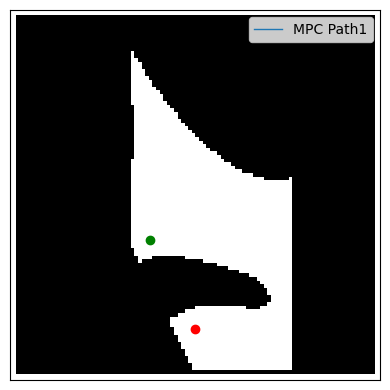

In [82]:
# =============================================================================
# 配置空间可视化环境设置
# =============================================================================
def plotCSpaceTrajectory(lw=1, alpha=1.0):
    """
    在配置空间中绘制从起始点到目标点的轨迹
    参数：
    lw: 线宽，默认为1
    alpha: 透明度，默认为1.0（完全不透明）
    """
    plt.figure(figsize=(4,4), dpi=100)  # 创建正方形高分辨率图形
    ax = plt.gca()                      # 获取当前坐标轴
    plt.xticks([])                      # 移除x轴刻度标签
    plt.yticks([])                      # 移除y轴刻度标签
    
    # 设置坐标轴范围为关节限制范围
    plt.xlim(robot.q_min[0]-0.05, robot.q_max[0]+0.05)
    plt.ylim(robot.q_min[1]-0.05, robot.q_max[1]+0.05)

    # 绘制配置空间的可行性地图作为背景
    # 白色区域表示可行配置，黑色区域表示不可行配置（有碰撞或违反约束）
    plt.imshow(c_space, cmap='gray', 
               extent=[robot.q_min[0], robot.q_max[0], robot.q_min[1], robot.q_max[1]], 
               origin='lower')

    # 绘制起始和目标关节配置点
    plt.scatter(q0[0], q0[1], c='r', marker='o')  # 红色圆点：起始配置
    plt.scatter(qd[0], qd[1], c='g', marker='o')  # 绿色圆点：目标配置

    # 遍历获取位置记录
    for i in range(mpc_loop_num):
        q_log = pos_profile_log[i]
        direct_pts_log = direct_profile_log[i]
        # label = 'MPC Path' if i == 0 else None  # 只为第一个路径添加标签
        label = 'MPC Path' + f'{i+1}'  # 为每个路径添加不同标签
        plt.plot(q_log[:, 0], q_log[:, 1], '-', label=label,lw=lw, alpha=alpha)
        label = 'Direct 0-via-point Path' if i == 0 else None  # 只为第一个路径添加标签
        if len(direct_pts_log)>0:
            plt.plot(direct_pts_log[:, 0], direct_pts_log[:, 1], 'r--', label=label)
    
    plt.legend(loc='upper right')  # 添加图例
    plt.tight_layout()  # 自动调整布局
    plt.show()  # 显示图形

# 绘制配置空间轨迹
plotCSpaceTrajectory()

In [83]:
# """
# 绘制机械臂在笛卡尔空间（任务空间）中的配置和轨迹的一帧
# 参数：
# it: 迭代次数，0表示初始状态，其他值表示优化过程中的状态
# """
# def plotCartesianSpace(it, save_figures=False):
#     plt.figure(dpi=100)  # 创建高分辨率图形
#     plt.xticks([])       # 移除x轴刻度标签
#     plt.yticks([])       # 移除y轴刻度标签
#     ax = plt.gca()       # 获取当前坐标轴
    
#     # 绘制碰撞环境（障碍物和边界）
#     plotEnvironment(ax, env)
    
#     # 绘制起始和目标配置的机械臂
#     plotRobot(ax, robot, q0, color='r')  # 红色：起始配置
#     plotRobot(ax, robot, qd, color='g')  # 绿色：目标配置

#     # 根据迭代次数选择要显示的途径点
#     if it == 0:
#         q_via_best = q_init  # 初始状态：使用初始猜测的途径点
#     else:
#         q_via_best = sol.via_best_list[it-1]  # 优化过程：使用对应迭代的最优途径点
    
#     # 绘制当前最优途径点对应的机械臂配置，因为已经把最初和最末状态画了，所以只画途经点的机械臂状态
#     plotRobot(ax, robot, q_via_best, color='m')  # 紫红色：最优途径点配置

#     # 生成并绘制末端执行器轨迹
#     q_traj, _, _ = vpsto.vptraj.get_trajectory(q_via_best, q0, qT=qd, dqT=np.zeros(2)) # 给定w，使用基函数和时间T生成时域连续的轨迹
#     q_traj = q_traj.squeeze(axis=0)  # 移除多余维度

#     # 计算末端执行器在笛卡尔空间中的轨迹
#     X = np.empty((len(q_traj), 3, 2))
#     for i in range(len(q_traj)):
#         X[i] = robot.fk(q_traj[i])  # 正向运动学转换
    
#     # 绘制末端执行器轨迹（紫红色曲线）
#     plt.plot(X[:,-1,0], X[:,-1,1], c='m', alpha=0.8)

#     plt.tight_layout()  # 自动调整布局

#     # 如果启用保存图片，则保存到文件
#     if save_figures:
#         plt.savefig('task_space_'+str(it)+'.png', dpi=200)

# """可视化优化过程中的笛卡尔空间轨迹测试"""
# print("绘制笛卡尔空间轨迹对比...")
# plotCartesianSpace(0)   # 绘制初始状态（优化前）
# plotCartesianSpace(20)  # 绘制第20次迭代的状态（优化过程中）


In [84]:
"""优化空间的分析和可视化"""
# """
# 检查通过指定途径点的轨迹是否发生碰撞或违反约束
# 参数：
# q_via: 途径点的关节角度
# 返回：布尔值，True表示轨迹不可行（有碰撞或违反约束）
# """
# def isViaCollision(q_via):
#     # 生成通过途径点的完整轨迹
#     q_traj, _, _ = vpsto.vptraj.get_trajectory(q_via, q0, qT=qd, dqT=np.zeros(2), T=1.0) # 使用一个途径点q_via生成轨迹
#     q_traj = q_traj.squeeze(axis=0)  # 移除多余的维度
    
#     # 检查关节限制约束
#     if np.any(q_traj <= robot.q_min) or np.any(q_traj >= robot.q_max):
#         return True  # 违反关节限制
    
#     # 将关节空间轨迹转换为笛卡尔空间轨迹
#     X = np.empty((len(q_traj), 3, 2))  # (时间步, 关节数, 坐标维度)
#     for i in range(len(q_traj)):
#         X[i] = robot.fk(q_traj[i])  # 正向运动学转换

#     # 检查工作空间边界约束
#     if np.any(X[:,:,0] < env.x_min[0]) or np.any(X[:,:,0] > env.x_max[0]) or np.any(X[:,:,1] < env.x_min[1]) or np.any(X[:,:,1] > env.x_max[1]):
#         return True  # 超出工作空间边界

#     # 检查与障碍物的碰撞
#     if np.any(env.isTrajectoryCollision(X)):
#         return True  # 发生碰撞
    
#     return False  # 轨迹可行

# # 遍历所有的途经点组合，检查途经点的可行性，如果可行，则计算最优执行时间
# # 重用之前定义的采样点
# n1_samples = 100  # 第一关节的采样点数
# n2_samples = 100  # 第二关节的采样点数
# q1 = np.linspace(robot.q_min[0], robot.q_max[0], n1_samples)  # 第一关节角度采样
# q2 = np.linspace(robot.q_min[1], robot.q_max[1], n2_samples)  # 第二关节角度采样

# # 初始化结果矩阵
# q_via_collision = np.zeros((n1_samples, n2_samples))  # 途径点轨迹可行性矩阵
# q_via_T = np.zeros((n1_samples, n2_samples))          # 途径点轨迹最优时间矩阵

# # 遍历所有可能的途径点
# for i in range(n1_samples):
#     print(100*i/n1_samples, end='\r')  # 显示进度
#     for j in range(n2_samples):
#         q_via = np.array([q1[i], q2[j]])  # 当前途径点配置
        
#         # 检查通过当前途径点的轨迹是否可行
#         if isViaCollision(q_via):
#             q_via_collision[j,i] = 0  # 轨迹不可行，标记为0
#             # i和j的顺序是因为矩阵的行对应第二个关节，列对应第一个关节
#         else:
#             q_via_collision[j,i] = 1  # 轨迹可行，标记为1
#             # 计算通过该途径点的最优执行时间
#             q_via_T[j,i] = vpsto.vptraj.get_min_duration(q_via, q0, qT=qd, dqT=np.zeros(2))
# print("配置空间采样完成！")

# def plotOptSpace(it,save_figures_path=None):
#     """
#     绘制优化空间，显示不同途径点的优化潜力
#     该图结合了可行性和执行时间信息，帮助理解优化算法的搜索策略
#     参数：
#     it: 迭代次数，0表示初始状态，其他值表示优化过程中的状态
#     """
#     plt.figure(figsize=(4,4), dpi=100)  # 创建正方形高分辨率图形
#     ax = plt.gca()                      # 获取当前坐标轴
#     plt.xticks([])                      # 移除x轴刻度标签
#     plt.yticks([])                      # 移除y轴刻度标签
    
#     # 设置坐标轴范围为关节限制范围
#     plt.xlim(robot.q_min[0], robot.q_max[0])
#     plt.ylim(robot.q_min[1], robot.q_max[1])

#     # 计算基于执行时间的奖励值
#     # 执行时间越短的途径点获得越高的奖励
#     R = np.exp(-1e-1*q_via_T)  # 指数衰减：时间越长，奖励越低
    
#     # 绘制优化空间地图：结合可行性和时间奖励
#     # 亮度表示该途径点的优化价值：越亮表示越可行且执行时间越短
#     plt.imshow(q_via_collision*R, cmap='gray', 
#                extent=[robot.q_min[0], robot.q_max[0], robot.q_min[1], robot.q_max[1]], 
#                origin='lower')

#     if it == 0:
#         # 初始状态：只显示初始猜测的途径点
#         plt.scatter(q_init[0], q_init[1], c='m', marker='o')
#     else:
#         # 优化过程：显示最优解和所有候选解
#         q_via_best = sol.via_best_list[it-1]  # 获取当前迭代的最优途径点
#         plt.scatter(q_via_best[0], q_via_best[1], c='m', marker='o')  # 紫红色：最优点
        
#         # 根据损失值计算奖励值，用于颜色编码候选解
#         costs = sol.loss_list[it-1]  # 获取当前迭代的所有候选解损失值
#         rewards = np.exp(-costs / np.mean(costs))  # 将损失转换为奖励
        
#         # 绘制所有候选解的途径点
#         for i in range(vpsto.opt.pop_size):
#             # 根据奖励值设置颜色：奖励高的偏绿色，奖励低的偏红色
#             c = (1-rewards[i], rewards[i], 0)
#             q_via = sol.candidates_list[it-1][i]  # 候选途径点
#             plt.scatter(q_via[0], q_via[1], color=c, marker='o', alpha=0.8)

#     plt.tight_layout()  # 自动调整布局

#     # 如果启用保存图片，则保存到文件
#     if save_figures_path is not None:
#         plt.savefig(save_figures_path + '/via_space_'+str(it)+'.png', dpi=200)

# """绘制优化空间中的轨迹优化过程"""
# print("绘制优化空间中的轨迹优化对比...")
# plotOptSpace(0)   # 绘制初始状态（优化前）
# plotOptSpace(20)  # 绘制第20次迭代的状态（优化过程中）

'优化空间的分析和可视化'